# ¡Hola Omar! 😊

Mi nombre es **Alejandro Castellanos** y hoy tengo el placer de ser el revisor de tu proyecto.

Voy a revisar todo tu código con detalle, buscando tanto los puntos fuertes como aquellos en los que podrías mejorar. Te dejaré comentarios a lo largo del notebook, destacando lo que has hecho bien y sugiriendo ajustes donde sea necesario. Si encuentro algún error, no te preocupes, te lo haré saber de forma clara y te daré información útil para que puedas corregirlo en la próxima iteración. Si en algún punto tienes comentarios, siéntete libre de dejarlos también.


Encontrarás mis comentarios específicos dentro de cajas verdes, amarillas o rojas, es muy importante que no muevas, modifiques o borres mis comentarios, con el fin de tener un seguimiento adecuado de tu proceso:


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si todo está perfecto.
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si tu código está bien pero se puede mejorar o hay algún detalle que le hace falta.
</div>

<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si de pronto hace falta algo o existe algún problema con tu código o conclusiones.
</div>

Puedes responderme de esta forma:
<div class="alert alert-block alert-info">
<b>Respuesta del estudiante</b> <a class=“tocSkip”></a>
</div>

A continuación te dejaré un comentario general con mi valoración del proyecto. **¡Mi objetivo es que sigas aprendiendo y mejorando con cada paso!**


----

<div class="alert alert-block alert-success">
<b>Comentario General del revisor (1ra Iteración)</b> <a class=“tocSkip”></a>


Omar, has desarrollado un trabajo sólido en la preparación y el análisis de los datos, mostrando buen manejo en la limpieza, transformación y exploración de la información, además de una interpretación acertada de los patrones por género, región y en las pruebas de hipótesis, lo que deja ver una comprensión clara del caso de estudio. 

Para fortalecer aún más tu proyecto, te conviene cuidar algunos detalles de precisión metodológica, como evitar pasos redundantes en el procesamiento, delimitar de forma exacta los periodos que analizas, complementar ciertas interpretaciones con sus valores numéricos correspondientes, verificar supuestos estadísticos antes de aplicar pruebas y cerrar el análisis con una conclusión general que reúna los hallazgos principales de manera ordenada. 

Vas por un muy buen camino, y con estos ajustes tus trabajso pueden quedar más claros, consistentes y mejores 

¡Te deseo muchos éxitos en tu próximo Sprint! 🚀

*Estado del Proyecto:* **Aprobado**

</div>

-----

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats as st

Se cargan las librerias

In [2]:
df = pd.read_csv('/datasets/games.csv')
print(df.info())
df.head(50)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB
None


,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN
5,Tetris,GB,1989.0,Puzzle,23.20,2.26,4.22,0.58,NaN,NaN,NaN
6,New Super Mario Bros.,DS,2006.0,Platform,11.28,9.14,6.50,2.88,89.0,8.5,E
7,Wii Play,Wii,2006.0,Misc,13.96,9.18,2.93,2.84,58.0,6.6,E
8,New Super Mario Bros. Wii,Wii,2009.0,Platform,14.44,6.94,4.70,2.24,87.0,8.4,E
9,Duck Hunt,NES,1984.0,Shooter,26.93,0.63,0.28,0.47,NaN,NaN,NaN


Se carga la informacióm

In [3]:
# Paso 2: Preparación de datos
# Nombres de columnas a minúsculas
df.columns = df.columns.str.lower()

# Conversión de tipos y manejo de 'tbd'
df['year_of_release'] = df['year_of_release'].astype('Int64')
df['user_score'] = df['user_score'].replace('tbd', np.nan)
df['user_score'] = df['user_score'].astype(float)
df['year_of_release'] = df['year_of_release'].astype('Int64')
df['rating'] = df['rating'].fillna('Unknown')
# Calcular ventas totales
df['total_sales'] = df[['na_sales', 'eu_sales', 'jp_sales', 'other_sales']].sum(axis=1)

df.head(25)

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E,82.54
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,NaN,NaN,Unknown,40.24
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E,35.52
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.0,8.0,E,32.77
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,Unknown,31.38
5,Tetris,GB,1989,Puzzle,23.20,2.26,4.22,0.58,NaN,NaN,Unknown,30.26
6,New Super Mario Bros.,DS,2006,Platform,11.28,9.14,6.50,2.88,89.0,8.5,E,29.80
7,Wii Play,Wii,2006,Misc,13.96,9.18,2.93,2.84,58.0,6.6,E,28.91
8,New Super Mario Bros. Wii,Wii,2009,Platform,14.44,6.94,4.70,2.24,87.0,8.4,E,28.32
9,Duck Hunt,NES,1984,Shooter,26.93,0.63,0.28,0.47,NaN,NaN,Unknown,28.31


Cambiamos los tipos de datos de la columna 'year_of release' a enteros por que los años no tienen decimales. Los valores 'TBD' fueron cambiados a 'NaN', pues al dejarlo como texto, python no podría calcular promedios, correlaciones y demás cuestiones estadísticas que requieren valores numéricos, además de agregar el valor "Unknown" a los videojuegos sin rating, esto es por que deben ser incluidos en el análisis siendo tomados en cuenta como un conjunto de videojuegos cuyo rating es desconocido.

<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteración)</b> <a class=“tocSkip”></a>

Buen trabajo con la preparación de los datos, ya que normalizas los nombres de columnas, tratas correctamente los valores `'tbd'` en `user_score` y calculas `total_sales` sumando las ventas regionales. Revisa que la conversión de `year_of_release` a `Int64` aparece dos veces, por lo que puedes dejarla solo una vez para evitar redundancia. También sería útil revisar los valores ausentes antes de rellenar `rating` con `'Unknown'`, así mantienes claro qué decisión estás tomando. 
</div>

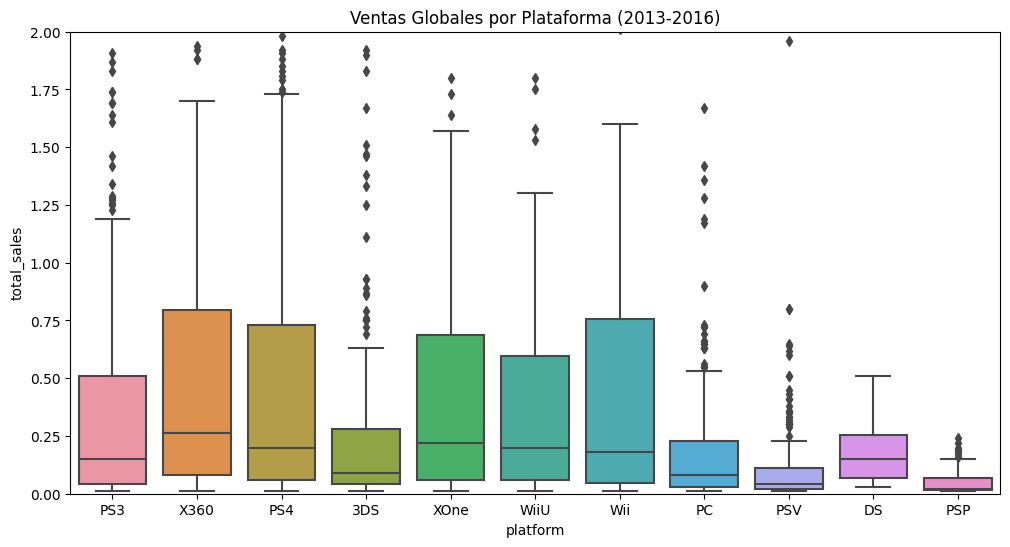

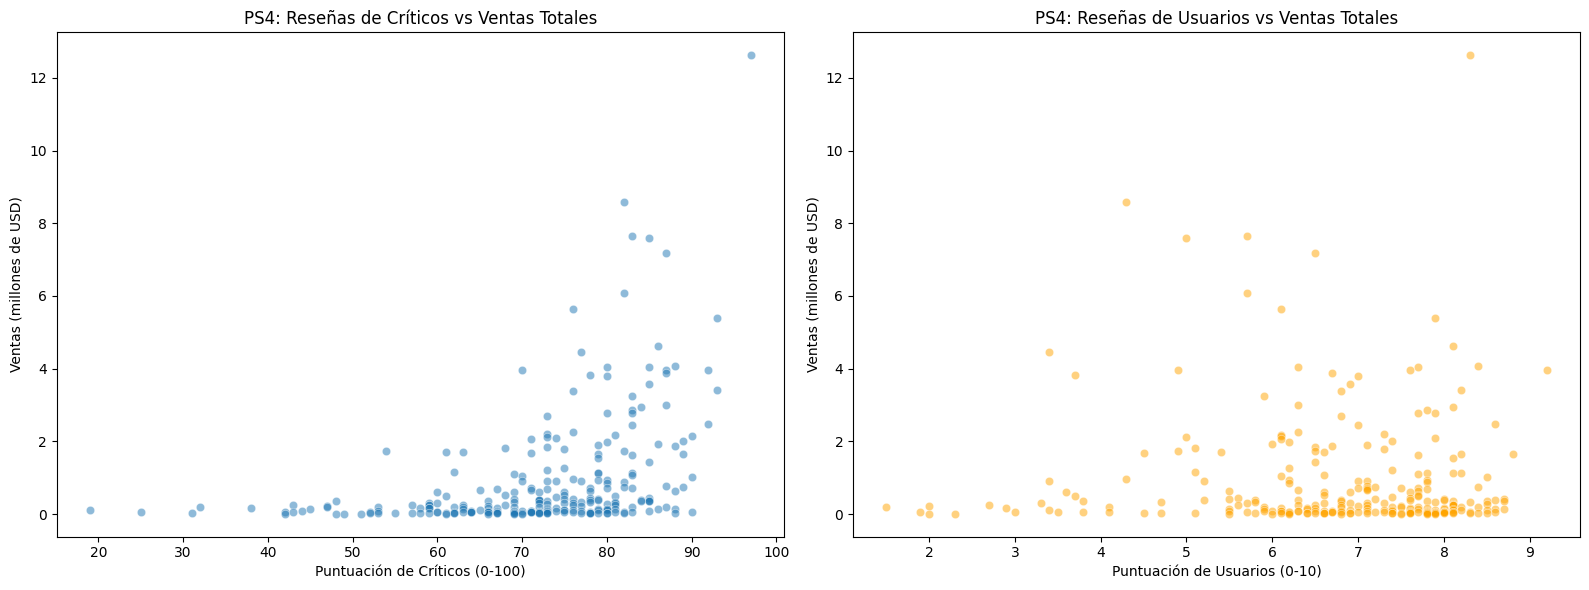

Correlación Críticas-Ventas (PS4): 0.40656790206178095


In [4]:
# Paso 3: Análisis de datos
# Filtrar por periodo relevante (2013-2016) para predecir 2017
df_recent = df[df['year_of_release'] >= 2013].copy()

# Ventas por plataforma
platform_sales = df_recent.pivot_table(index='platform', values='total_sales', aggfunc='sum').sort_values(by='total_sales', ascending=False)

# diagramas de caja para ventas globales por plataforma
plt.figure(figsize=(12,6))
sns.boxplot(data=df_recent, x='platform', y='total_sales')
plt.ylim(0, 2) # zoom para ver mejor la distribución
plt.title('Ventas Globales por Plataforma (2013-2016)')
plt.show()

# --- Análisis de Reseñas vs Ventas ---

# Seleccionamos una plataforma popular para el análisis (ej. PS4)
ps4_data = df_recent[df_recent['platform'] == 'PS4']

# Eliminamos nulos específicamente para este cálculo para evitar errores
ps4_critic = ps4_data[ps4_data['critic_score'].notna()]
ps4_user = ps4_data[ps4_data['user_score'].notna()]

# Creación de gráficos de dispersión
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico para Críticos
sns.scatterplot(data=ps4_critic, x='critic_score', y='total_sales', ax=ax[0], alpha=0.5)
ax[0].set_title('PS4: Reseñas de Críticos vs Ventas Totales')
ax[0].set_xlabel('Puntuación de Críticos (0-100)')
ax[0].set_ylabel('Ventas (millones de USD)')

# Gráfico para Usuarios
sns.scatterplot(data=ps4_user, x='user_score', y='total_sales', ax=ax[1], alpha=0.5, color='orange')
ax[1].set_title('PS4: Reseñas de Usuarios vs Ventas Totales')
ax[1].set_xlabel('Puntuación de Usuarios (0-10)')
ax[1].set_ylabel('Ventas (millones de USD)')

plt.tight_layout()
plt.show()

# Correlación Críticas vs Ventas (Ejemplo: PS4)
ps4_data = df_recent[df_recent['platform'] == 'PS4']
correlation_critic = ps4_data['critic_score'].corr(ps4_data['total_sales'])
print(f"Correlación Críticas-Ventas (PS4): {correlation_critic}")


Se observa que la puntuación de los críticos puede tener cierta influencia en la venta de videojuegos de mejor calificación pues graficamente parece haber una correlación positiva, mientras que las puntuaciones de los usuarios parecen ser menos relevantes en la venta de videojuegos de menor puntuación ya que algunos con baja calificación han tenido fuertes ventas.

<div class="alert alert-block alert-warning">
<b>Comentario del revisor (1ra Iteración)</b> <a class=“tocSkip”></a>

Avanzaste bien en el análisis al enfocarte en un periodo reciente, construir `platform_sales` y relacionar reseñas con `total_sales` mediante gráficos y correlación. Hay un detalle importante en la interpretación del filtro `year_of_release >= 2013`, porque incluye todos los años posteriores que existan en el dataset y no solo 2013–2016, así que conviene usar una condición cerrada como `between(2013, 2016)`. También falta calcular la correlación con `user_score`, ya que el gráfico se genera pero no queda respaldado con el valor numérico. 
</div>

Análisis de rentabilidad por género (ordenado por mediana):
              count     sum      mean  median
genre                                        
Shooter         187  232.98  1.245882   0.450
Sports          214  150.65  0.703972   0.240
Platform         74   42.63  0.576081   0.225
Role-Playing    292  145.89  0.499623   0.125
Fighting         80   35.31  0.441375   0.125
Racing           85   39.89  0.469294   0.120
Action          766  321.87  0.420196   0.110
Simulation       62   21.76  0.350968   0.100
Misc            155   62.82  0.405290   0.100
Strategy         56   10.08  0.180000   0.080
Puzzle           17    3.17  0.186471   0.060
Adventure       245   23.64  0.096490   0.030


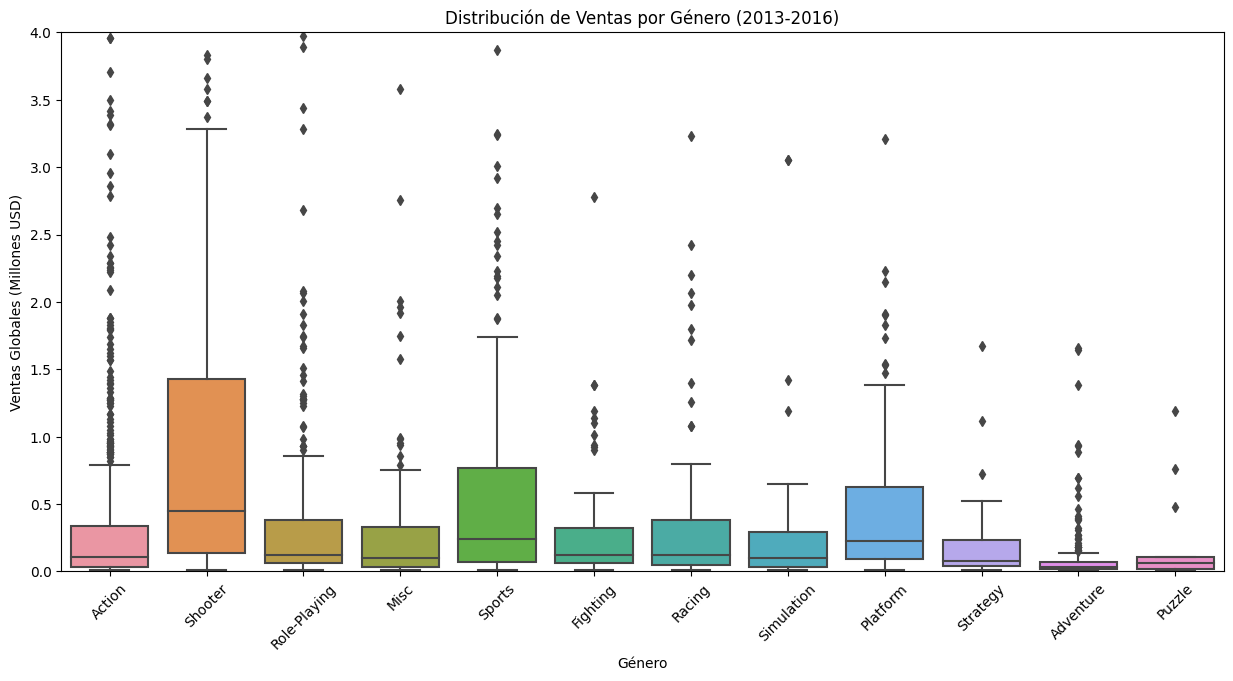

In [5]:
# --- PASO 3: Análisis de Géneros ---

# 1. Agrupamos por género y calculamos métricas clave (usando el periodo relevante 2013-2016)
genre_analysis = df_recent.groupby('genre')['total_sales'].agg(['count', 'sum', 'mean', 'median']).sort_values(by='median', ascending=False)

print("Análisis de rentabilidad por género (ordenado por mediana):")
print(genre_analysis)

# 2. Visualización: Ventas Globales por Género (Boxplot)
plt.figure(figsize=(15, 7))
sns.boxplot(data=df_recent, x='genre', y='total_sales')
plt.title('Distribución de Ventas por Género (2013-2016)')
plt.xlabel('Género')
plt.ylabel('Ventas Globales (Millones USD)')
plt.xticks(rotation=45)
plt.ylim(0, 4) # Limitamos el eje Y para ver mejor las cajas sin los valores atípicos extremos
plt.show()

Para 2017, se recomienda priorizar los Shooters por su alta rentabilidad constante y los juegos de Acción solo si son títulos de alto presupuesto (AAA), debido a la enorme competencia en ese género.

<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteración)</b> <a class=“tocSkip”></a>

Vas organizando bien el análisis por género al usar `groupby('genre')` con métricas como `count`, `sum`, `mean` y `median`, lo que ayuda a comparar popularidad y rentabilidad sin depender solo de ventas totales. 


</div>

--- ANÁLISIS DE PLATAFORMAS POR REGIÓN ---

Top 5 Plataformas en Norteamérica:
          Ventas (M$)  Cuota (%)
platform                        
PS4            108.74  24.842933
XOne            93.12  21.274360
X360            81.66  18.656188
PS3             63.50  14.507322
3DS             38.20   8.727239

Top 5 Plataformas en Europa:
          Ventas (M$)  Cuota (%)
platform                        
PS4            141.09  35.971241
PS3             67.81  17.288326
XOne            51.59  13.152997
X360            42.52  10.840578
3DS             30.96   7.893328

Top 5 Plataformas en Japón:
          Ventas (M$)  Cuota (%)
platform                        
3DS             67.81  48.167353
PS3             23.35  16.586163
PSV             18.59  13.205001
PS4             15.96  11.336838
WiiU            10.88   7.728371


--- ANÁLISIS DE GÉNEROS POR REGIÓN ---

Top 5 Géneros en Norteamérica:
              Ventas (M$)  Cuota (%)
genre                               
Action             126

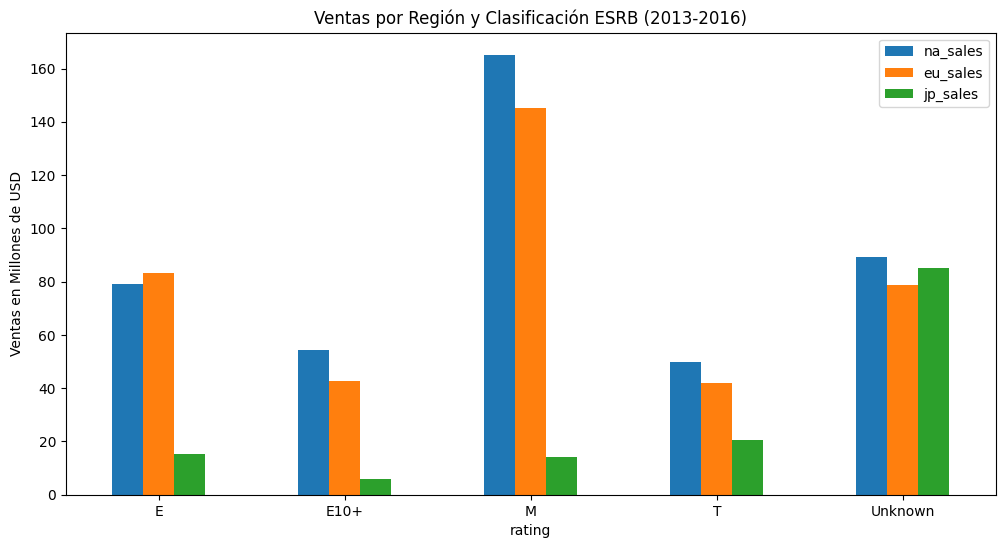

In [6]:
# Paso 4: Perfil de usuario por región
def top_5_by_region(df, group_col, region_sales):
    # Agrupamos por la columna deseada y sumamos ventas de la región
    report = df.groupby(group_col)[region_sales].sum().sort_values(ascending=False).head(5)
    # Calculamos el porcentaje de mercado (cuota) sobre el total de la región
    total_region = df[region_sales].sum()
    report_percent = (report / total_region) * 100
    return pd.DataFrame({
        'Ventas (M$)': report,
        'Cuota (%)': report_percent
    })

# Lista de regiones
regions = [('na_sales', 'Norteamérica'), ('eu_sales', 'Europa'), ('jp_sales', 'Japón')]

print("--- ANÁLISIS DE PLATAFORMAS POR REGIÓN ---")
for col, name in regions:
    print(f"\nTop 5 Plataformas en {name}:")
    print(top_5_by_region(df_recent, 'platform', col))

print("\n" + "="*40 + "\n")

print("--- ANÁLISIS DE GÉNEROS POR REGIÓN ---")
for col, name in regions:
    print(f"\nTop 5 Géneros en {name}:")
    print(top_5_by_region(df_recent, 'genre', col))

# --- IMPACTO DE LA CLASIFICACIÓN ESRB ---
print("\n" + "="*40 + "\n")
print("--- VENTAS POR RATING ESRB ---")

# Rellenamos nulos en rating con 'Unknown' para ver el impacto de juegos no clasificados
df_recent['rating'] = df_recent['rating'].fillna('Unknown')

esrb_analysis = df_recent.groupby('rating')[['na_sales', 'eu_sales', 'jp_sales']].sum()
print(esrb_analysis)

# Visualización del impacto ESRB
esrb_analysis.plot(kind='bar', figsize=(12, 6), rot=0)
plt.title('Ventas por Región y Clasificación ESRB (2013-2016)')
plt.ylabel('Ventas en Millones de USD')
plt.show()

Se observa que en USA y Europa PS4 es el más popular mientras que en Japón es el Nintendo DS. En cuanto a calificación las ventas en Japón son menores para videojuegos con alguna calificación determinada a diferencia de USA y Europa en donde solo en clasificación E las ventas son mayores en Europa.

<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteración)</b> <a class=“tocSkip”></a>

Omar has logrado identificar claramente las diferencias entre América del Norte, Europa y Japón, no solo en términos de plataformas y géneros predominantes, sino también en la influencia de las clasificaciones ESRB, lo que refleja tu capacidad para conectar datos con tendencias culturales y de comportamiento. 

</div>

In [7]:
# Paso 5: Prueba de hipótesis

# Preparación de los datos: filtramos nulos para que el test funcione
xone_scores = df_recent[(df_recent['platform'] == 'XOne') & (df_recent['user_score'].notna())]['user_score']
pc_scores = df_recent[(df_recent['platform'] == 'PC') & (df_recent['user_score'].notna())]['user_score']

# Formulación:
# H0: El promedio de user_score de Xbox One es IGUAL al de PC.
# H1: El promedio de user_score de Xbox One es DIFERENTE al de PC.

alpha = 0.05 # Umbral de significancia del 5%

results = st.ttest_ind(xone_scores, pc_scores, equal_var=False)

print(f"Media Xbox One: {xone_scores.mean():.2f}")
print(f"Media PC: {pc_scores.mean():.2f}")
print(f"Valor p: {results.pvalue}")

if results.pvalue < alpha:
    print("Rechazamos la hipótesis nula: existe evidencia suficiente para decir que las calificaciones son diferentes.")
else:
    print("No rechazamos la hipótesis nula: no hay evidencia de una diferencia significativa.")

# Preparación de los datos
action_scores = df_recent[(df_recent['genre'] == 'Action') & (df_recent['user_score'].notna())]['user_score']
sports_scores = df_recent[(df_recent['genre'] == 'Sports') & (df_recent['user_score'].notna())]['user_score']

# Formulación:
# H0: El promedio de user_score para Acción es IGUAL al de Deportes.
# H1: El promedio de user_score para Acción es DIFERENTE al de Deportes.

results_genre = st.ttest_ind(action_scores, sports_scores, equal_var=False)

print(f"Media Acción: {action_scores.mean():.2f}")
print(f"Media Deportes: {sports_scores.mean():.2f}")
print(f"Valor p: {results_genre.pvalue}")

if results_genre.pvalue < alpha:
    print("Rechazamos la hipótesis nula: los usuarios califican de forma distinta los juegos de Acción y Deportes.")
else:
    print("No rechazamos la hipótesis nula.")

Media Xbox One: 6.52
Media PC: 6.27
Valor p: 0.14759594013430463
No rechazamos la hipótesis nula: no hay evidencia de una diferencia significativa.
Media Acción: 6.84
Media Deportes: 5.24
Valor p: 1.4460039700704315e-20
Rechazamos la hipótesis nula: los usuarios califican de forma distinta los juegos de Acción y Deportes.


Se usó la prueba t de Student para muestras independientes porque se compararon las medias de dos poblaciones distintas (usuarios de diferentes plataformas o géneros) y se aplicó la Prueba t de Welch ya que es más segura porque no asume que las dos poblaciones tienen la misma varianza (el tamaño de la muestra de PC es distinto al de Xbox One).

Si el valor p es menor que alfa (0.05), la probabilidad de que la diferencia sea casualidad es muy baja (menos del 5%), por lo que decimos que la diferencia es estadísticamente significativa

<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteración)</b> <a class=“tocSkip”></a>

Omar aplicaste correctamente las prueba de hipótesis comparando las distribuciones dos muestras independientes e interpretando de manera acertada el *p-value* obtenido y su relación con la hipótesis nula

</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor (1ra Iteración)</b> <a class=“tocSkip”></a>

Te recomiendo realizar previamente una prueba de [Levene](https://www.educaopen.com/digital-lab/blog/educacion-digital/prueba-de-levene) para evaluar la igualdad de las varianzas, lo que te permitirá configurar adecuadamente el parámetro **equal_var** en la función `ttest_ind`. Esto servirá para tener una interpretación más precisa de los resultados además garantizará que la prueba t sea estadísticamente válida.

</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor (1ra Iteración)</b> <a class=“tocSkip”></a>

Recuerda siempre incluir tu conclusión general del proyecto que has realizado, en la cual se reúna y resuma de manera ordenada toda la información obtenida dándole un enfoque con relación al caso de estudio, permitiendo así cerrar el estudio con una visión integral y bien fundamentada.

</div>